# Phase 6: Model Evaluation & Independent Testing Pipeline
## Đề tài: Phát hiện và Giải thích Tấn công Mạng IoT (CICIoT2023) với XAI

> **Nguyên Tắc Phân Tách Tuyệt Đối (Strict Separation of Concerns):**
> - **Phase 5**: Thử nghiệm nhiều mô hình, thuật toán, siêu tham số trên tập Train (`phase5_experiments/`).
> - **Phase 6**: Đánh giá độc lập trên **Validation Set** để so sánh và lựa chọn mô hình tối ưu. Sau đó kiểm định khách quan trên **Test Set** độc lập (chưa từng gặp) và đo kiểm độ trễ suy luận thời gian thực.

### Cấu Trúc Thư Mục Kết Quả (Deliverables Structure):
```text
phase6_evaluation/
│
├── README.md                          # Hướng dẫn tổng quan toàn bộ pipeline Phase 6
│
├── runs/                              # Đóng gói độc lập từng đợt đánh giá mô hình
│   ├── eval_001/                      # Đợt 1: Random Forest Baseline (exp_001)
│   │   ├── config.yaml                # Cấu hình siêu tham số, metadata, liên kết Phase 5
│   │   ├── metadata.json              # Thông số môi trường hệ thống & thời gian
│   │   ├── validation/                # Đánh giá trên tập Validation (25,551 mẫu)
│   │   │   ├── confusion_matrix.png   # Ma trận nhầm lẫn 8 lớp chuẩn Fig. 4a bài báo
│   │   │   ├── classification_report.json
│   │   │   ├── classification_report.txt
│   │   │   ├── roc_auc.json           # Macro, Weighted & per-class One-vs-Rest AUC
│   │   │   └── predictions.csv        # Dự đoán chi tiết từng mẫu kiểm thử
│   │   ├── test/                      # Đánh giá trên tập Test độc lập (25,552 mẫu)
│   │   │   ├── confusion_matrix.png
│   │   │   ├── classification_report.json
│   │   │   ├── classification_report.txt
│   │   │   ├── roc_auc.json
│   │   │   └── predictions.csv
│   │   └── performance/               # Đo kiểm độ trễ suy luận (Inference Latency)
│   │       └── latency.json           # Median/p95 latency (ms) & Throughput (mẫu/s)
│   │
│   ├── eval_002/                      # Đợt 2: Gradient Boosting Baseline (exp_002)
│   ├── eval_003/                      # Đợt 3: Decision Tree Baseline (exp_003)
│   ├── eval_004/                      # Đợt 4: Ensemble Blending Model (exp_004)
│   └── eval_005/                      # Đợt 5: XGBoost / Boosting Tuned (exp_005)
│
├── comparison/                        # Tổng hợp so sánh liên đợt & bảng xếp hạng
│   ├── evaluation_summary.csv         # Bảng xếp hạng chi tiết tất cả các đợt
│   ├── evaluation_comparison.xlsx     # Báo cáo Excel 2 sheet (Model Comparison + Per-Class)
│   ├── per_class_summary.csv          # Chi tiết Precision/Recall/F1 cho cả 8 lớp tấn công
│   ├── stability_summary.csv          # Đánh giá độ ổn định Mean ± Std qua 3 seed
│   └── evaluation_comparison.png      # Biểu đồ so sánh 4 chiều trực quan
│
└── final/                             # Mô hình quán quân được tuyển chọn
    ├── selected_model/                # Trọng số mô hình chiến thắng (model.joblib)
    ├── final_metrics.json             # Các chỉ số kiểm thử cuối cùng trên Test set
    └── final_report/                  # Báo cáo tổng kết toàn diện cho đề tài
        ├── README.md
        ├── executive_summary.md
        └── final_confusion_matrix.png
```

--- 
## Cell 1: Thiết lập Môi trường & Tự động Kết nối Google Drive
Tự động phát hiện Google Drive tại `/content/drive/MyDrive/do_an` để điều hướng lưu trữ trực tiếp toàn bộ thư mục `phase6_evaluation/` khi chạy trên Google Colab.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ==============================================================================
# Cell 1: Cấu hình Môi trường Google Colab & Điều hướng Lưu trữ Drive
# ==============================================================================
import os
import sys
import gc
import time
import json
import yaml
import shutil
import warnings
from datetime import datetime
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Kiểm tra Google Colab Drive
COLAB_DRIVE_PATH = '/content/drive/MyDrive/do_an'
if os.path.exists(COLAB_DRIVE_PATH):
    BASE_DIR = COLAB_DRIVE_PATH
    print(f"[INFO] Phát hiện Google Colab: Điều hướng lưu trữ vào {BASE_DIR}")
else:
    BASE_DIR = '.'
    print("[INFO] Đang chạy trên máy cục bộ (Local Environment).")

EXP_ROOT = os.path.join(BASE_DIR, 'phase5_experiments') if BASE_DIR != '.' else 'phase5_experiments'
EVAL_ROOT = os.path.join(BASE_DIR, 'phase6_evaluation') if BASE_DIR != '.' else 'phase6_evaluation'
MODELS_DIR = os.path.join(BASE_DIR, 'models') if BASE_DIR != '.' else 'models'

for d in [EVAL_ROOT, os.path.join(EVAL_ROOT, 'runs'), os.path.join(EVAL_ROOT, 'comparison'), os.path.join(EVAL_ROOT, 'final')]:
    os.makedirs(d, exist_ok=True)

print(f"Thư mục nguồn Phase 5:       {os.path.abspath(EXP_ROOT)}")
print(f"Thư mục đánh giá Phase 6:    {os.path.abspath(EVAL_ROOT)}")

[INFO] Phát hiện Google Colab: Điều hướng lưu trữ vào /content/drive/MyDrive/do_an
Thư mục nguồn Phase 5:       /content/drive/MyDrive/do_an/phase5_experiments
Thư mục đánh giá Phase 6:    /content/drive/MyDrive/do_an/phase6_evaluation


--- 
## Cell 2: Nạp Dữ liệu & Phân vùng Tập Validation và Test Độc lập
Nạp ma trận đặc trưng từ Phase 4 (`data/X_train_selected.pkl` - 25 đặc trưng tối ưu) và nhãn (`data/y_train_balanced.pkl`).
Tách nghiêm ngặt tập holdout 20% (chưa từng tham gia huấn luyện Phase 5) thành 2 tập độc lập:
- **Validation Set (50%)**: Dùng để xếp hạng mô hình và chọn cấu hình tối ưu.
- **Test Set (50%)**: Dùng làm tập kiểm thử độc lập cuối cùng (Unseen Final Evaluation).

In [6]:
# ==============================================================================
# Cell 2: Nạp Dữ liệu & Phân chia Tập Validation / Test Độc lập
# ==============================================================================
from sklearn.model_selection import train_test_split

CLASS_NAMES_8 = [
    'BruteForce',
    'DDoS',
    'DoS',
    'Mirai',
    'Normal',
    'Recon',
    'Spoofing',
    'Web-Based'
]

ATTACK_TO_8_CLASS = {
    'DictionaryBruteForce': 'BruteForce', 'BruteForce': 'BruteForce',
    'DDoS-ACK_Fragmentation': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS', 'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS', 'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SYN_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS', 'DDoS-SynonymousIP_Flood': 'DDoS',
    'DDoS-TCP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS': 'DDoS',
    'DoS-HTTP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-UDP_Flood': 'DoS', 'DoS': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai', 'Mirai': 'Mirai',
    'BenignTraffic': 'Normal', 'Benign': 'Normal', 'Normal': 'Normal',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PingSweep': 'Recon',
    'Recon-PortScan': 'Recon', 'VulnerabilityScan': 'Recon', 'Recon': 'Recon',
    'DNS_Spoofing': 'Spoofing', 'MITM-ArpSpoofing': 'Spoofing', 'Spoofing': 'Spoofing',
    'Backdoor_Malware': 'Web-Based', 'BrowserHijacking': 'Web-Based', 'CommandInjection': 'Web-Based',
    'SqlInjection': 'Web-Based', 'Uploading_Attack': 'Web-Based', 'XSS': 'Web-Based',
    'Web': 'Web-Based', 'Web-Based': 'Web-Based', 'Malware': 'Web-Based'
}

# 1. Nạp ma trận đặc trưng
x_paths = ['data/X_train_selected.pkl', os.path.join(BASE_DIR, 'data/X_train_selected.pkl'), 'X_train_reduced.pkl']
x_file = next((p for p in x_paths if os.path.exists(p)), None)
if not x_file:
    raise FileNotFoundError(f"Không tìm thấy ma trận đặc trưng: {x_paths}")

print(f"Nạp đặc trưng từ: {x_file} ...")
X = joblib.load(x_file)
feature_names = list(X.columns) if hasattr(X, 'columns') else [f"feature_{i}" for i in range(X.shape[1])]

# 2. Nạp nhãn mục tiêu
y_paths = ['data/y_train_balanced.pkl', os.path.join(BASE_DIR, 'data/y_train_balanced.pkl'), 'data/y_train.pkl']
y_file = next((p for p in y_paths if os.path.exists(p)), None)
if not y_file:
    raise FileNotFoundError(f"Không tìm thấy nhãn mục tiêu: {y_paths}")

print(f"Nạp nhãn từ: {y_file} ...")
y_dict = joblib.load(y_file)
raw_labels = y_dict['target_name'] if isinstance(y_dict, dict) and 'target_name' in y_dict else y_dict['label_name']
y_8class = np.array([ATTACK_TO_8_CLASS.get(str(lbl).strip(), 'Web-Based') for lbl in raw_labels])

# 3. Tách tập holdout 20% (chưa từng tham gia huấn luyện Phase 5)
_, X_holdout, _, y_holdout = train_test_split(
    X, y_8class,
    test_size=0.2,
    stratify=y_8class,
    random_state=123
)

# 4. Chia đôi holdout thành 50% Validation và 50% Test độc lập
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout,
    test_size=0.5,
    stratify=y_holdout,
    random_state=42
)

print(f"\nTổng dữ liệu:           {len(X):,} dòng x {X.shape[1]} đặc trưng")
print(f"Tập Validation (Phục vụ chọn Model): {X_val.shape[0]:,} mẫu")
print(f"Tập Test (Kiểm thử độc lập cuối):    {X_test.shape[0]:,} mẫu")
print("8 Classes:", CLASS_NAMES_8)

Nạp đặc trưng từ: data/X_train_selected.pkl ...
Nạp nhãn từ: data/y_train_balanced.pkl ...

Tổng dữ liệu:           267,062 dòng x 25 đặc trưng
Tập Validation (Phục vụ chọn Model): 26,706 mẫu
Tập Test (Kiểm thử độc lập cuối):    26,707 mẫu
8 Classes: ['BruteForce', 'DDoS', 'DoS', 'Mirai', 'Normal', 'Recon', 'Spoofing', 'Web-Based']


--- 
## Cell 3: Định Nghĩa Bộ Điều Phối Đánh Giá Mô Hình (`NotebookEvaluationRunner`)
Xây dựng class đóng gói toàn bộ quy trình đánh giá chuẩn hoá theo đúng cấu trúc thư mục yêu cầu:
- `config.yaml`: Thông số cấu hình, liên kết Phase 5, siêu tham số, ngày giờ.
- `metadata.json`: Môi trường hệ thống, danh sách đặc trưng, tổng hợp metrics.
- `validation/`: Ma trận nhầm lẫn 8 lớp, classification report (JSON + TXT), ROC-AUC và predictions chi tiết.
- `test/`: Toàn bộ các deliverables tương tự trên tập Test độc lập.
- `performance/`: Đo kiểm độ trễ suy luận 1 mẫu (ms) và tốc độ throughput (mẫu/s).

In [7]:
# ==============================================================================
# Cell 3: Định nghĩa NotebookEvaluationRunner
# ==============================================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

class NotebookEvaluationRunner:
    """
    Điều phối việc đánh giá mô hình và lưu trữ có cấu trúc theo chuẩn:
    runs/eval_xxx/
      ├── config.yaml
      ├── metadata.json
      ├── validation/
      ├── test/
      └── performance/
    """
    def __init__(self, eval_root=EVAL_ROOT, exp_root=EXP_ROOT, class_names=CLASS_NAMES_8):
        self.eval_root = eval_root
        self.exp_root = exp_root
        self.class_names = class_names
        self.runs_dir = os.path.join(eval_root, 'runs')
        self.comp_dir = os.path.join(eval_root, 'comparison')
        self.final_dir = os.path.join(eval_root, 'final')
        for d in [self.runs_dir, self.comp_dir, self.final_dir]:
            os.makedirs(d, exist_ok=True)

    def _evaluate_split(self, model, X, y, split_name, out_dir):
        os.makedirs(out_dir, exist_ok=True)
        t0 = time.time()
        y_pred = model.predict(X)
        try:
            y_prob = model.predict_proba(X)
        except Exception:
            y_prob = None
        eval_time = time.time() - t0

        # Scalars
        acc = accuracy_score(y, y_pred)
        prec_m = precision_score(y, y_pred, labels=self.class_names, average='macro', zero_division=0)
        rec_m = recall_score(y, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_m = f1_score(y, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_w = f1_score(y, y_pred, labels=self.class_names, average='weighted', zero_division=0)

        # ROC-AUC
        roc_dict = {'roc_auc_macro': None, 'roc_auc_weighted': None, 'per_class_roc_auc': {}}
        if y_prob is not None:
            try:
                model_classes = list(getattr(model, 'classes_', self.class_names))
                c2idx = {c: i for i, c in enumerate(model_classes)}
                prob_ordered = np.zeros((len(X), len(self.class_names)), dtype=float)
                for j, c in enumerate(self.class_names):
                    if c in c2idx:
                        prob_ordered[:, j] = y_prob[:, c2idx[c]]
                roc_dict['roc_auc_macro'] = round(float(roc_auc_score(y, prob_ordered, labels=self.class_names, multi_class='ovr', average='macro')), 4)
                roc_dict['roc_auc_weighted'] = round(float(roc_auc_score(y, prob_ordered, labels=self.class_names, multi_class='ovr', average='weighted')), 4)
                for idx, c in enumerate(self.class_names):
                    y_bin = (y == c).astype(int)
                    if len(np.unique(y_bin)) > 1:
                        roc_dict['per_class_roc_auc'][c] = round(float(roc_auc_score(y_bin, prob_ordered[:, idx])), 4)
            except Exception as e:
                roc_dict['error'] = str(e)

        with open(os.path.join(out_dir, 'roc_auc.json'), 'w', encoding='utf-8') as f:
            json.dump(roc_dict, f, indent=4)

        # Classification Report
        cr_dict = classification_report(y, y_pred, labels=self.class_names, target_names=self.class_names, output_dict=True, zero_division=0)
        with open(os.path.join(out_dir, 'classification_report.json'), 'w', encoding='utf-8') as f:
            json.dump(cr_dict, f, indent=4)
        cr_text = classification_report(y, y_pred, labels=self.class_names, target_names=self.class_names, digits=4, zero_division=0)
        with open(os.path.join(out_dir, 'classification_report.txt'), 'w', encoding='utf-8') as f:
            f.write(f"=== CLASSIFICATION REPORT: [{split_name.upper()}] ===\n")
            f.write(f"Samples: {len(y):,} | Accuracy: {acc*100:.2f}% | F1-Macro: {f1_m*100:.2f}%\n\n")
            f.write(cr_text)

        # Confusion Matrix Heatmap (Chuẩn Fig. 4a bài báo)
        cm_raw = confusion_matrix(y, y_pred, labels=self.class_names)
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm_raw / row_sums) * 100.0

        annot_m = np.empty_like(cm_pct, dtype=object)
        for i in range(len(self.class_names)):
            for j in range(len(self.class_names)):
                v = cm_pct[i, j]
                annot_m[i, j] = f"{int(round(v))}%\n({cm_raw[i, j]:,})" if v >= 1.0 else (f"<1%\n({cm_raw[i, j]:,})" if v > 0 else "0%")

        fig, ax = plt.subplots(figsize=(9.5, 7.5), dpi=150)
        sns.heatmap(cm_pct, annot=annot_m, fmt="", cmap='YlGnBu', xticklabels=self.class_names, yticklabels=self.class_names, cbar_kws={'label': 'Độ chính xác nhận dạng (%)'}, ax=ax)
        ax.set_title(f"Ma Trận Nhầm Lẫn 8 Lớp [{split_name.upper()}]\nAccuracy: {acc*100:.2f}% | F1-Macro: {f1_m*100:.2f}%", fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel("Nhãn Dự Đoán (Predicted)", fontweight='bold')
        ax.set_ylabel("Nhãn Thực Tế (True)", fontweight='bold')
        plt.xticks(rotation=30, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, 'confusion_matrix.png'), bbox_inches='tight')
        plt.show()
        plt.close(fig)

        # Predictions CSV
        conf = np.max(y_prob, axis=1) if y_prob is not None else np.ones(len(y_pred))
        pd.DataFrame({
            'sample_idx': np.arange(len(y)),
            'true_label': y,
            'predicted_label': y_pred,
            'confidence': np.round(conf, 4),
            'is_correct': (y == y_pred).astype(int)
        }).to_csv(os.path.join(out_dir, 'predictions.csv'), index=False)

        return {
            'accuracy': round(float(acc), 4),
            'precision_macro': round(float(prec_m), 4),
            'recall_macro': round(float(rec_m), 4),
            'f1_macro': round(float(f1_m), 4),
            'f1_weighted': round(float(f1_w), 4),
            'roc_auc_macro': roc_dict['roc_auc_macro'],
            'eval_time': round(float(eval_time), 4),
            'cr_dict': cr_dict
        }

    def _measure_latency(self, model, X_sample, out_dir):
        os.makedirs(out_dir, exist_ok=True)
        # Warmup
        _ = model.predict(X_sample[:30])
        # Single sample measurement
        times = []
        for i in range(min(300, len(X_sample))):
            sample = X_sample.iloc[[i]] if hasattr(X_sample, 'iloc') else X_sample[i:i+1]
            t0 = time.perf_counter()
            _ = model.predict(sample)
            times.append((time.perf_counter() - t0) * 1000.0)
        # Batch
        t0 = time.perf_counter()
        _ = model.predict(X_sample)
        t_batch = time.perf_counter() - t0
        thru = len(X_sample) / t_batch if t_batch > 0 else 0
        latency_data = {
            'single_sample_latency_ms': {
                'mean': round(float(np.mean(times)), 4),
                'median_p50': round(float(np.percentile(times, 50)), 4),
                'p95': round(float(np.percentile(times, 95)), 4)
            },
            'batch_performance': {
                'throughput_samples_per_sec': round(float(thru), 2),
                'batch_ms_per_sample': round(float((t_batch / len(X_sample)) * 1000.0), 4)
            }
        }
        with open(os.path.join(out_dir, 'latency.json'), 'w', encoding='utf-8') as f:
            json.dump(latency_data, f, indent=4)
        return latency_data

    def run_evaluation(self, eval_id, phase5_exp_id, model_name, X_val, y_val, X_test, y_test, feature_names):
        print("=" * 75)
        print(f"ĐÁNH GIÁ ĐỢT: [{eval_id}] -> Mô hình: {model_name} (Liên kết: {phase5_exp_id})")
        print("=" * 75)

        run_dir = os.path.join(self.runs_dir, eval_id)
        val_dir = os.path.join(run_dir, 'validation')
        test_dir = os.path.join(run_dir, 'test')
        perf_dir = os.path.join(run_dir, 'performance')

        model_file = os.path.join(self.exp_root, phase5_exp_id, 'model', 'model.pkl')
        if not os.path.exists(model_file):
            raise FileNotFoundError(f"Không tìm thấy checkpoint mô hình: {model_file}")

        t_load = time.time()
        model = joblib.load(model_file)
        load_duration = time.time() - t_load

        # 1. Validation Set
        print(f"-> Đánh giá trên Validation Set ({len(X_val):,} mẫu)...")
        val_res = self._evaluate_split(model, X_val, y_val, 'validation', val_dir)
        print(f"   Validation Acc: {val_res['accuracy']*100:.2f}% | F1-Macro: {val_res['f1_macro']*100:.2f}% | ROC-AUC: {val_res['roc_auc_macro']}")

        # 2. Test Set
        print(f"-> Đánh giá trên Final Test Set ({len(X_test):,} mẫu)...")
        test_res = self._evaluate_split(model, X_test, y_test, 'test', test_dir)
        print(f"   Test Acc:       {test_res['accuracy']*100:.2f}% | F1-Macro: {test_res['f1_macro']*100:.2f}% | ROC-AUC: {test_res['roc_auc_macro']}")

        # 3. Latency
        perf_res = self._measure_latency(model, X_test, perf_dir)
        lat_p50 = perf_res['single_sample_latency_ms']['median_p50']
        thru = perf_res['batch_performance']['throughput_samples_per_sec']
        print(f"   Độ trễ trung vị: {lat_p50:.4f} ms / mẫu | Throughput: {thru:,.1f} mẫu/giây")

        # 4. Save config.yaml & metadata.json
        p5_cfg = {}
        p5_cfg_file = os.path.join(self.exp_root, phase5_exp_id, 'config.yaml')
        if os.path.exists(p5_cfg_file):
            with open(p5_cfg_file, 'r', encoding='utf-8') as f:
                p5_cfg = yaml.safe_load(f) or {}

        cfg_obj = {
            'evaluation': {'id': eval_id, 'date': datetime.now().strftime('%Y-%m-%d'), 'timestamp': datetime.now().isoformat()},
            'model': {'experiment_id': phase5_exp_id, 'name': model_name, 'model_path': model_file, 'hyperparameters': p5_cfg.get('hyperparameters', {})},
            'dataset': {'name': 'CICIoT2023', 'classes': 8, 'val_samples': len(X_val), 'test_samples': len(X_test)},
            'evaluation_sets': {'validation': True, 'test': True},
            'metrics': ['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted', 'roc_auc', 'confusion_matrix', 'inference_latency'],
            'random_seed': 42
        }
        with open(os.path.join(run_dir, 'config.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(cfg_obj, f, default_flow_style=False, sort_keys=False)

        meta_obj = {
            'eval_id': eval_id,
            'phase5_experiment_id': phase5_exp_id,
            'model_type': type(model).__name__,
            'val_metrics': val_res,
            'test_metrics': test_res,
            'latency': perf_res
        }
        with open(os.path.join(run_dir, 'metadata.json'), 'w', encoding='utf-8') as f:
            json.dump(meta_obj, f, indent=4)

        print(f"[OK] Đã lưu toàn bộ deliverables đợt [{eval_id}] vào: {run_dir}\n")
        return {
            'Eval ID': eval_id,
            'Phase 5 Experiment': phase5_exp_id,
            'Model Name': model_name,
            'Val Acc': val_res['accuracy'],
            'Val F1-Macro': val_res['f1_macro'],
            'Val ROC-AUC': val_res['roc_auc_macro'],
            'Test Acc': test_res['accuracy'],
            'Test F1-Macro': test_res['f1_macro'],
            'Test ROC-AUC': test_res['roc_auc_macro'],
            'Latency Median (ms)': lat_p50,
            'Throughput (samples/s)': thru
        }

eval_runner = NotebookEvaluationRunner(eval_root=EVAL_ROOT, exp_root=EXP_ROOT)
print("NotebookEvaluationRunner đã sẵn sàng thực thi từng đợt!")

NotebookEvaluationRunner đã sẵn sàng thực thi từng đợt!


--- 
## Cell 4: Đợt 1 — `eval_001` (Random Forest Baseline)
Đánh giá mô hình Random Forest (exp_001) trên cả tập Validation và Test độc lập.

ĐÁNH GIÁ ĐỢT: [eval_001] -> Mô hình: Random Forest Baseline (Liên kết: exp_001_rf_baseline)
-> Đánh giá trên Validation Set (26,706 mẫu)...


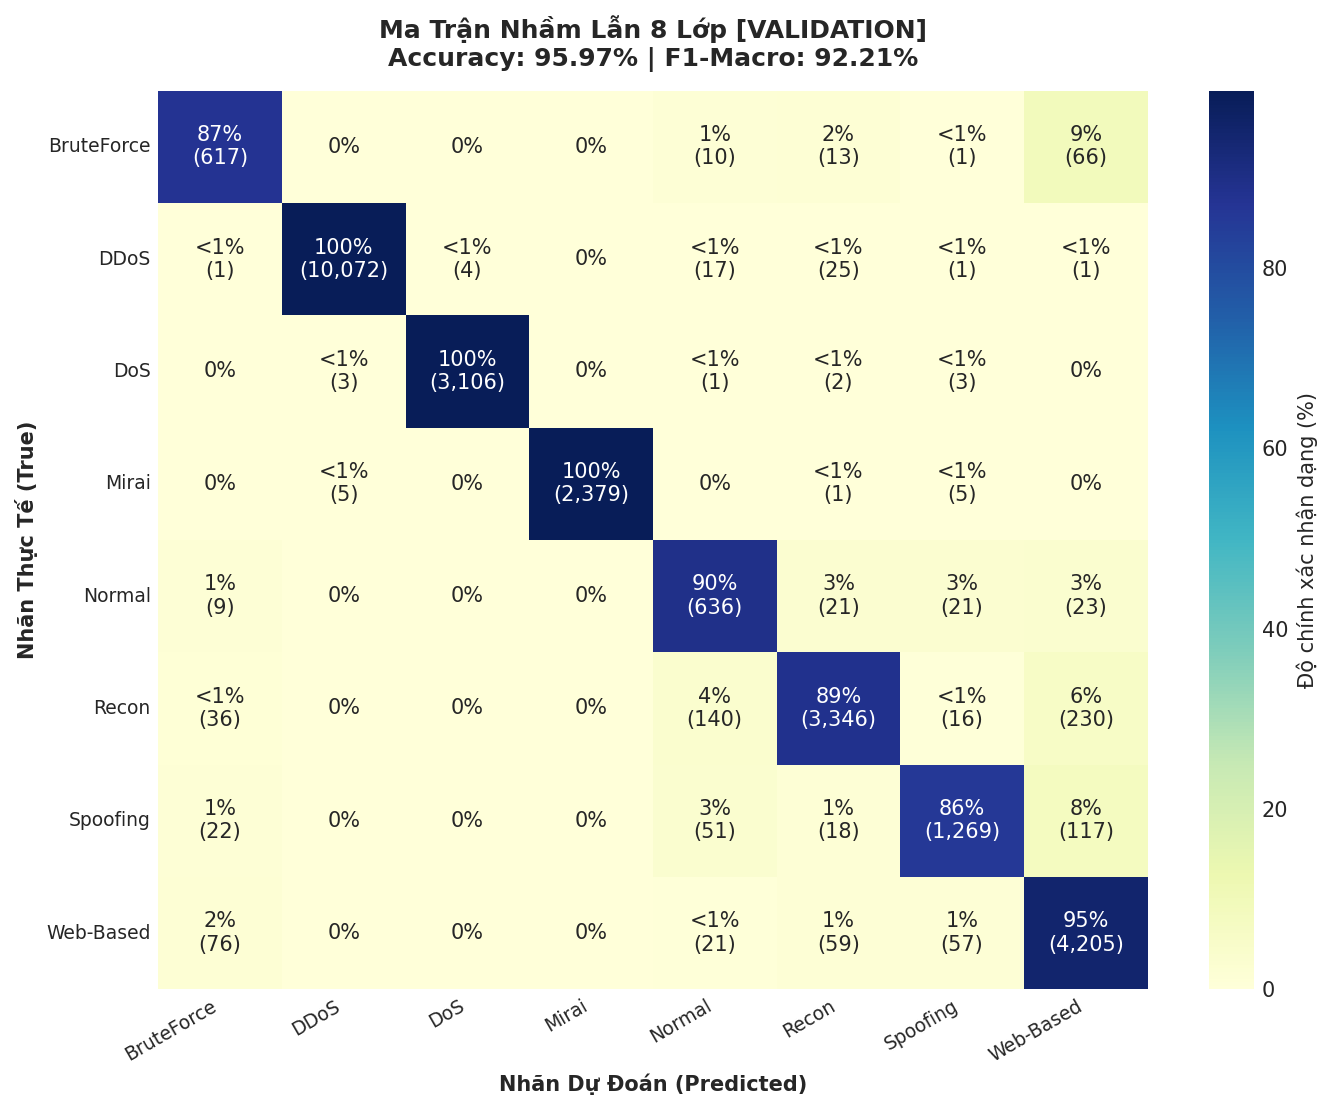

   Validation Acc: 95.97% | F1-Macro: 92.21% | ROC-AUC: 0.9976
-> Đánh giá trên Final Test Set (26,707 mẫu)...


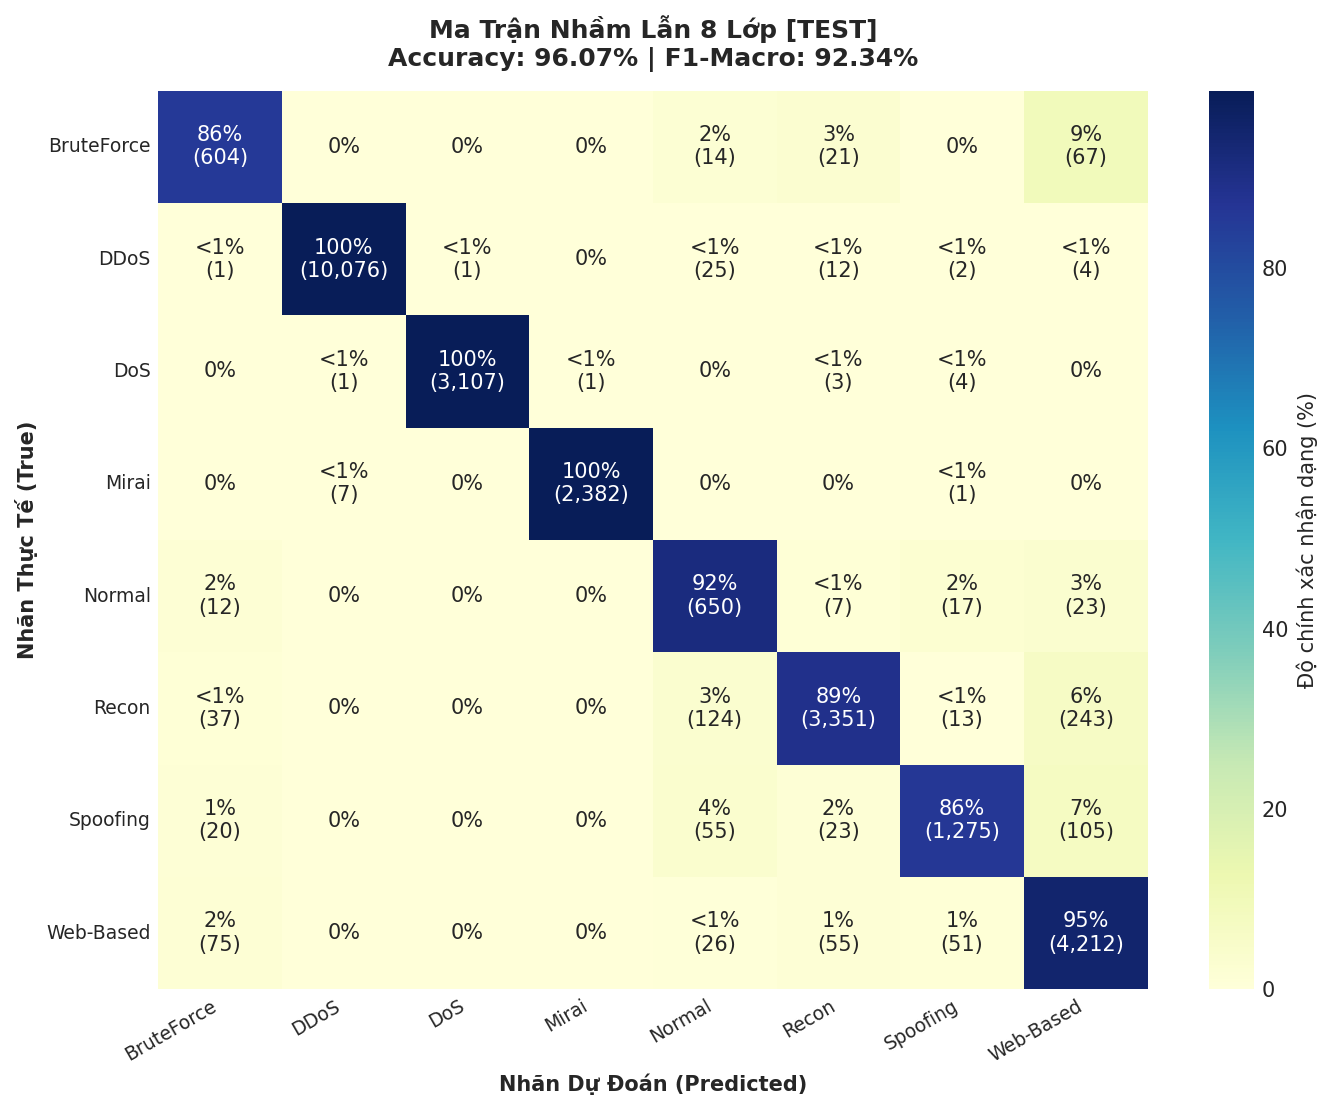

   Test Acc:       96.07% | F1-Macro: 92.34% | ROC-AUC: 0.9974
   Độ trễ trung vị: 24.4103 ms / mẫu | Throughput: 81,137.1 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_001] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_001



In [8]:
# ==============================================================================
# Cell 4: Chạy Đợt Đánh Giá 1 - Random Forest Baseline
# ==============================================================================
res_001 = eval_runner.run_evaluation(
    eval_id='eval_001',
    phase5_exp_id='exp_001_rf_baseline',
    model_name='Random Forest Baseline',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 5: Đợt 2 — `eval_002` (Gradient Boosting Baseline)
Đánh giá mô hình Gradient Boosting Baseline (exp_002) với các tham số chuẩn theo Table 2 của bài báo.

ĐÁNH GIÁ ĐỢT: [eval_002] -> Mô hình: Gradient Boosting Baseline (Liên kết: exp_002_xgboost_baseline)
-> Đánh giá trên Validation Set (26,706 mẫu)...


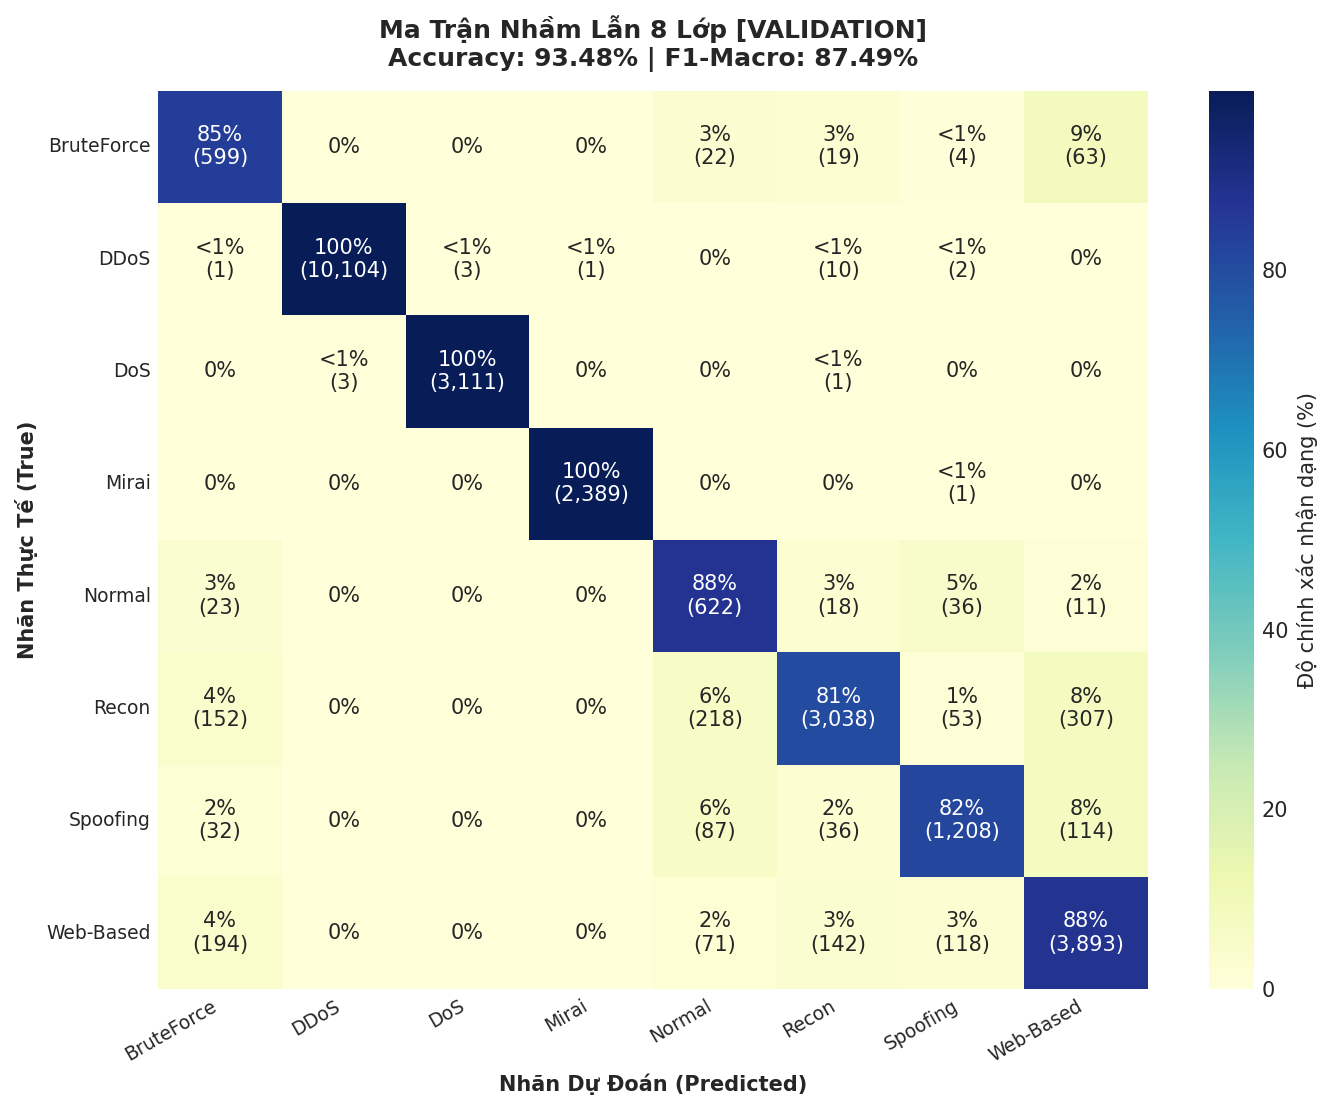

   Validation Acc: 93.48% | F1-Macro: 87.49% | ROC-AUC: 0.995
-> Đánh giá trên Final Test Set (26,707 mẫu)...


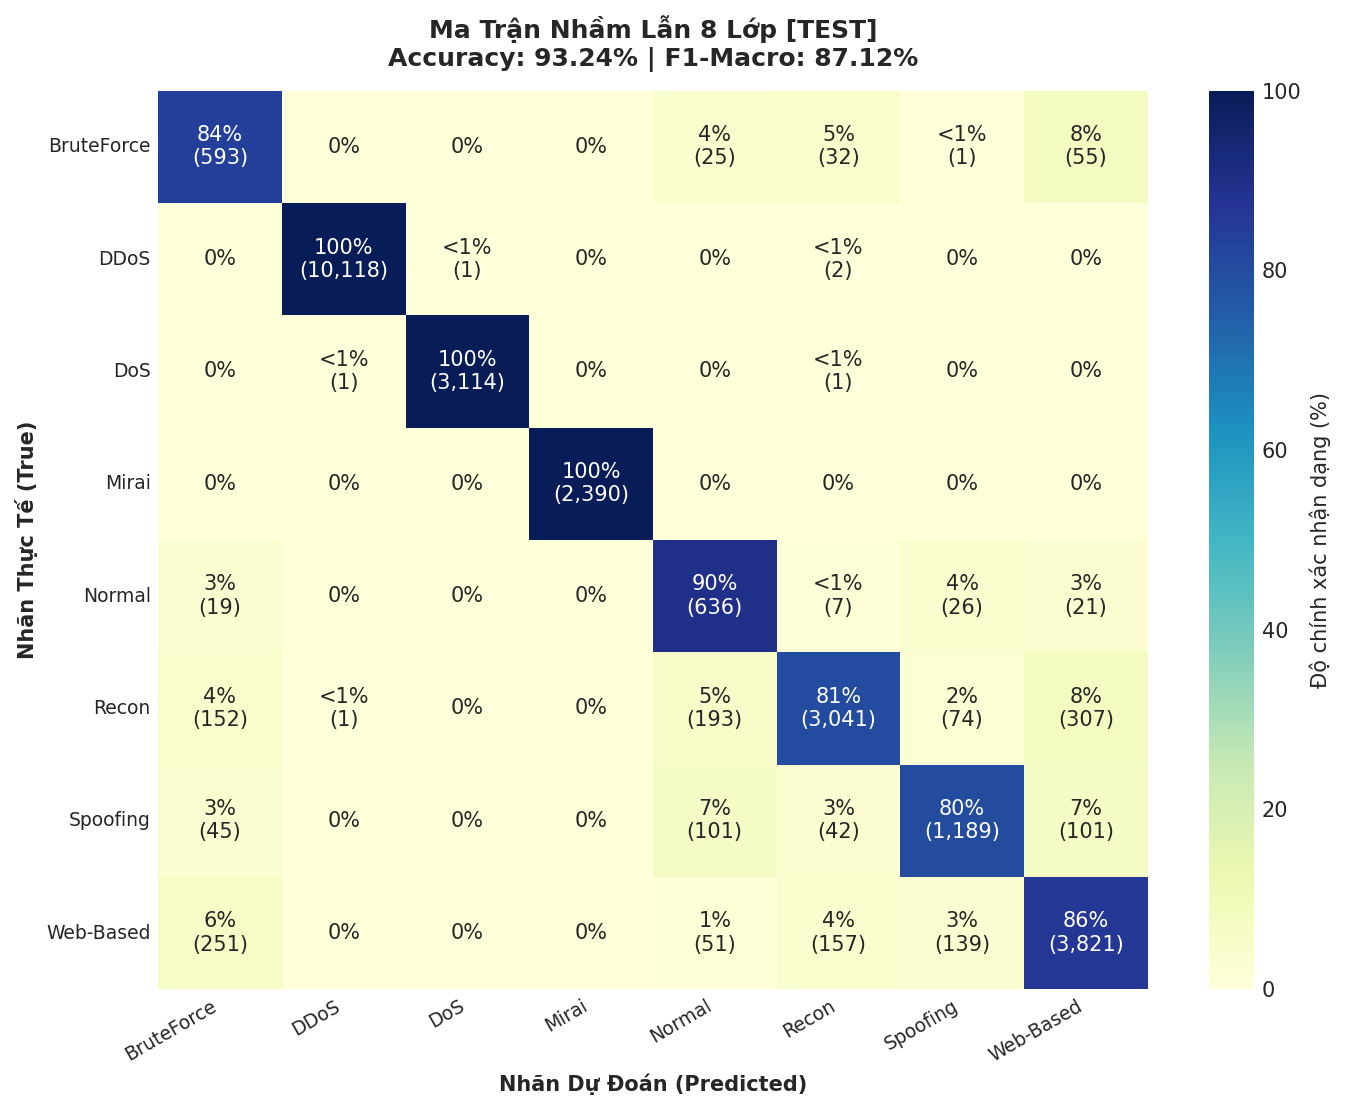

   Test Acc:       93.24% | F1-Macro: 87.12% | ROC-AUC: 0.9951
   Độ trễ trung vị: 7.0118 ms / mẫu | Throughput: 24,938.9 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_002] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_002



In [9]:
# ==============================================================================
# Cell 5: Chạy Đợt Đánh Giá 2 - Gradient Boosting Baseline
# ==============================================================================
res_002 = eval_runner.run_evaluation(
    eval_id='eval_002',
    phase5_exp_id='exp_002_xgboost_baseline',
    model_name='Gradient Boosting Baseline',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 6: Đợt 3 — `eval_003` (Decision Tree Baseline)
Đánh giá mô hình Decision Tree (exp_003) làm thước đo chuẩn về độ phức tạp và tốc độ suy luận nhanh nhất.

ĐÁNH GIÁ ĐỢT: [eval_003] -> Mô hình: Decision Tree Baseline (Liên kết: exp_003_decision_tree_baseline)
-> Đánh giá trên Validation Set (26,706 mẫu)...


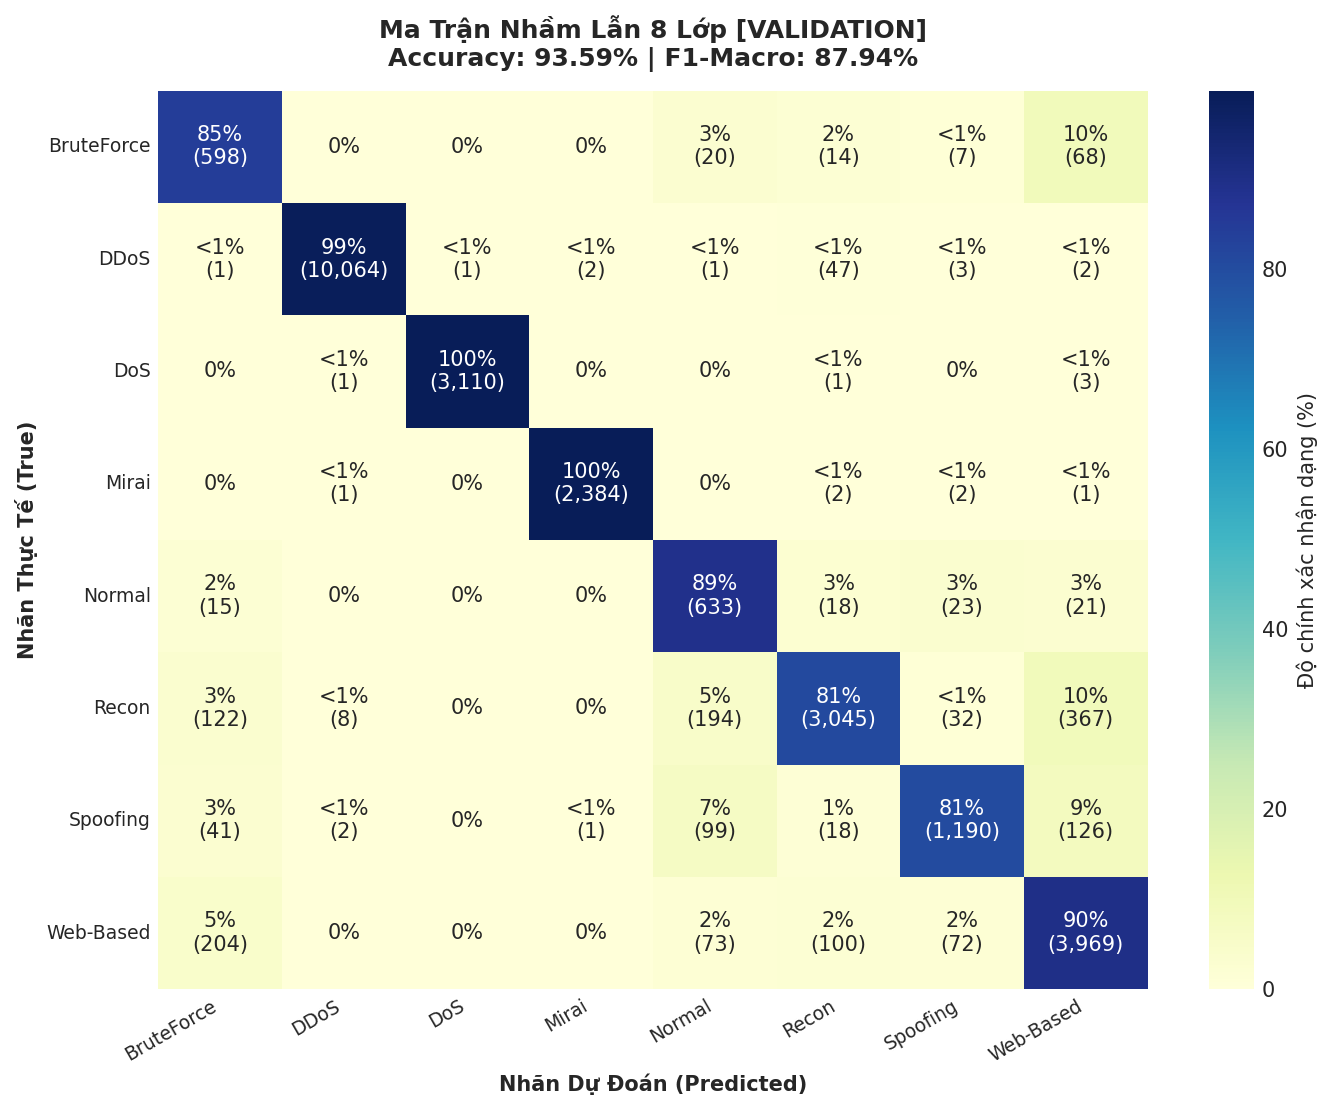

   Validation Acc: 93.59% | F1-Macro: 87.94% | ROC-AUC: 0.9913
-> Đánh giá trên Final Test Set (26,707 mẫu)...


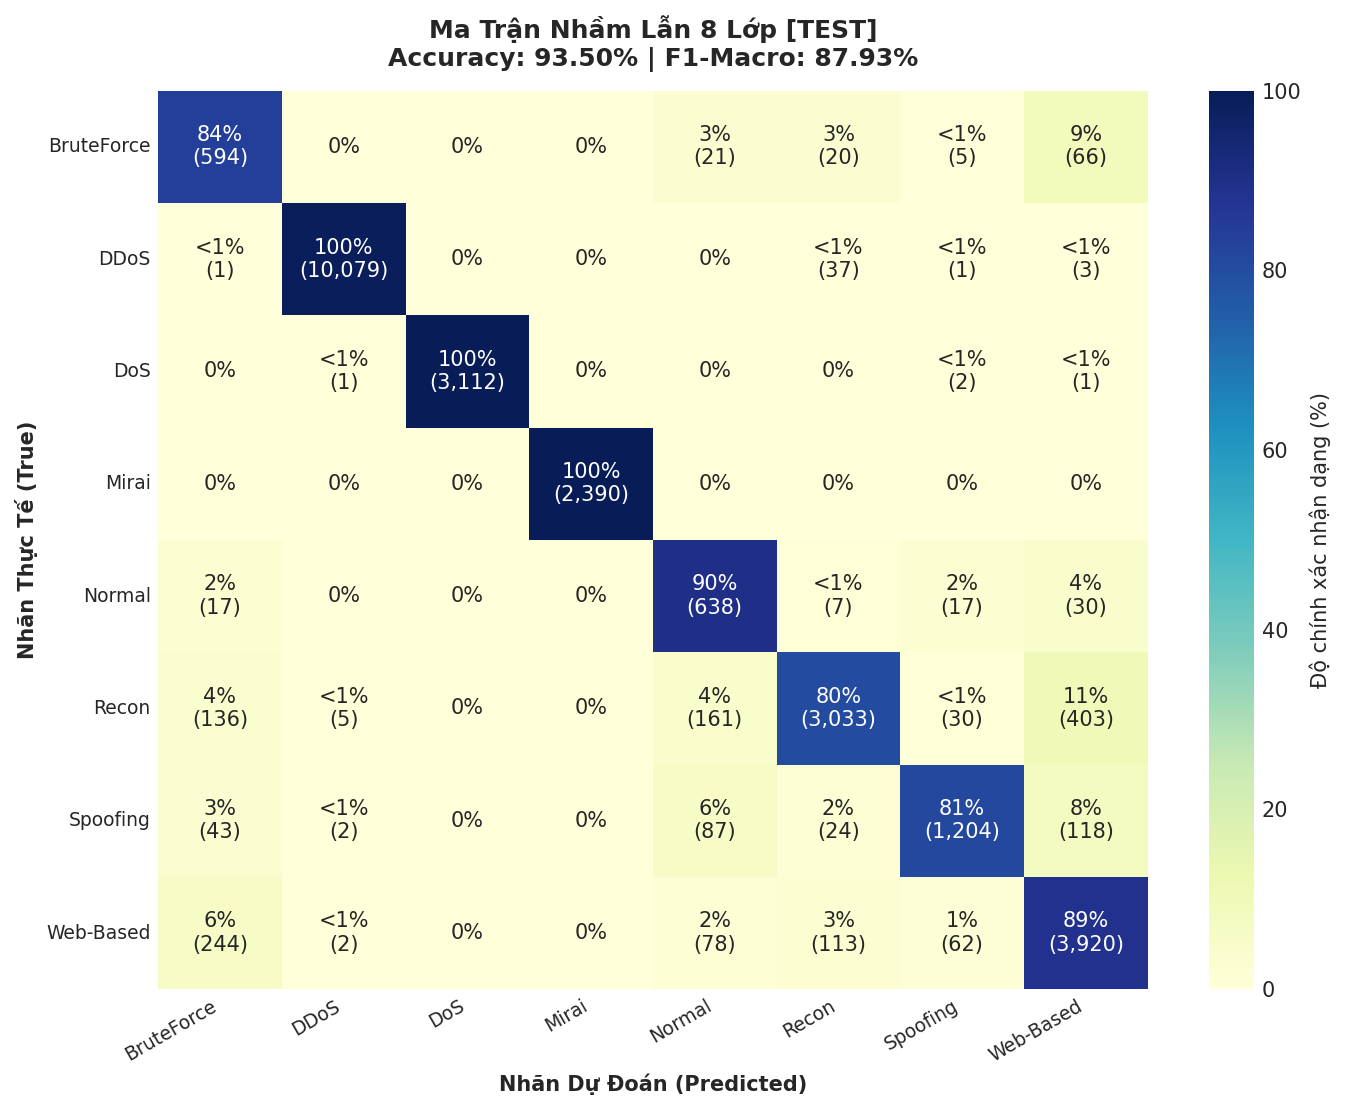

   Test Acc:       93.50% | F1-Macro: 87.93% | ROC-AUC: 0.9914
   Độ trễ trung vị: 0.7701 ms / mẫu | Throughput: 5,674,926.8 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_003] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_003



In [10]:
# ==============================================================================
# Cell 6: Chạy Đợt Đánh Giá 3 - Decision Tree Baseline
# ==============================================================================
res_003 = eval_runner.run_evaluation(
    eval_id='eval_003',
    phase5_exp_id='exp_003_decision_tree_baseline',
    model_name='Decision Tree Baseline',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 7: Đợt 4 — `eval_004` (Ensemble Blending Model)
Đánh giá mô hình học kết hợp đa tầng (Ensemble Blending kết hợp DT + RF + GB với Soft Voting theo Algorithm 1 của bài báo).

ĐÁNH GIÁ ĐỢT: [eval_004] -> Mô hình: Ensemble Blending Model (Liên kết: exp_004_ensemble_blending_paper)
-> Đánh giá trên Validation Set (26,706 mẫu)...


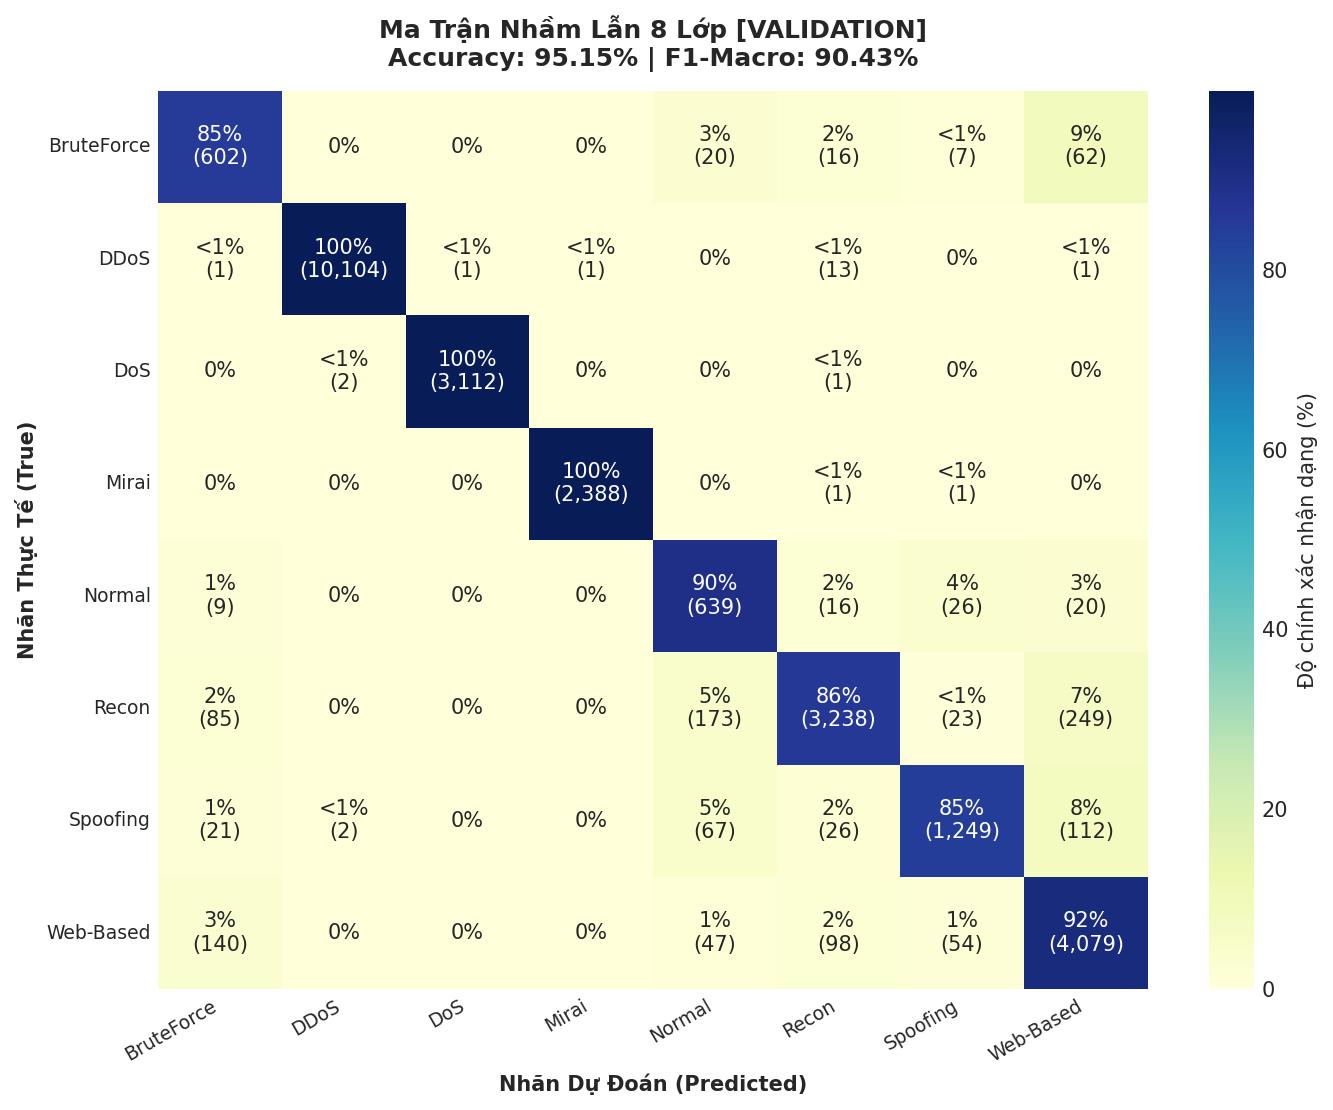

   Validation Acc: 95.15% | F1-Macro: 90.43% | ROC-AUC: 0.997
-> Đánh giá trên Final Test Set (26,707 mẫu)...


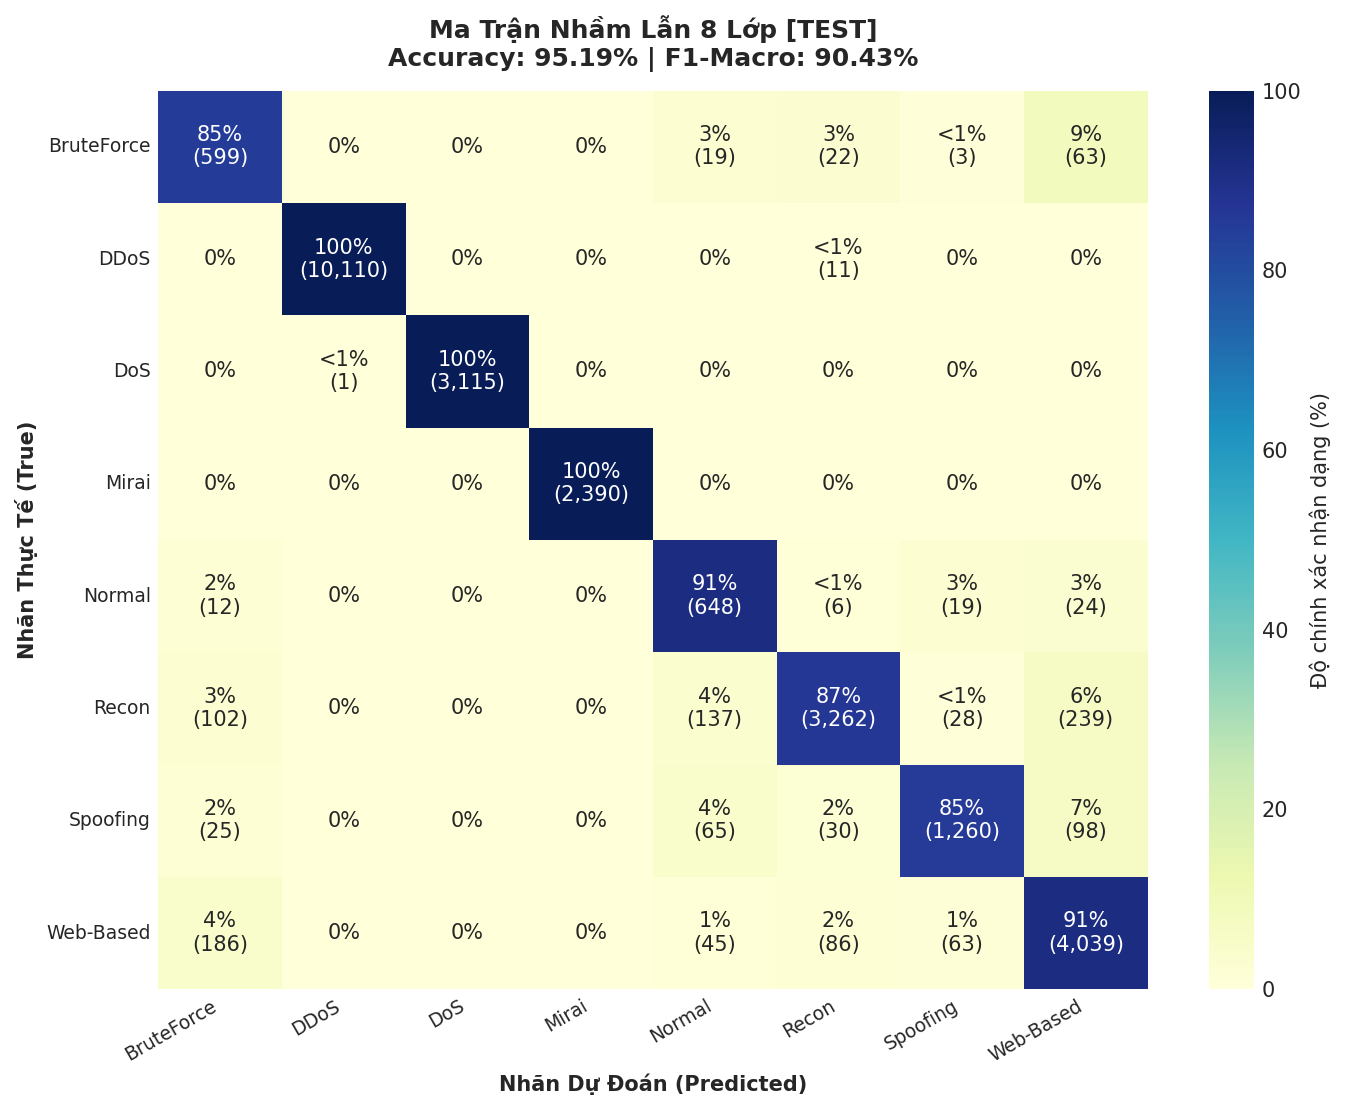

   Test Acc:       95.19% | F1-Macro: 90.43% | ROC-AUC: 0.9969
   Độ trễ trung vị: 36.4926 ms / mẫu | Throughput: 21,688.8 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_004] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_004



In [11]:
# ==============================================================================
# Cell 7: Chạy Đợt Đánh Giá 4 - Ensemble Blending Model
# ==============================================================================
res_004 = eval_runner.run_evaluation(
    eval_id='eval_004',
    phase5_exp_id='exp_004_ensemble_blending_paper',
    model_name='Ensemble Blending Model',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 8: Đợt 5 — `eval_005` (XGBoost / Boosting Tinh Chỉnh)
Đánh giá mô hình Gradient Boosting / XGBoost tinh chỉnh sâu với 150 cây lặp, độ sâu max_depth=6 và l2_regularization.

ĐÁNH GIÁ ĐỢT: [eval_005] -> Mô hình: XGBoost / Gradient Boosting Tuned (Liên kết: exp_005_xgboost_tuned)
-> Đánh giá trên Validation Set (26,706 mẫu)...


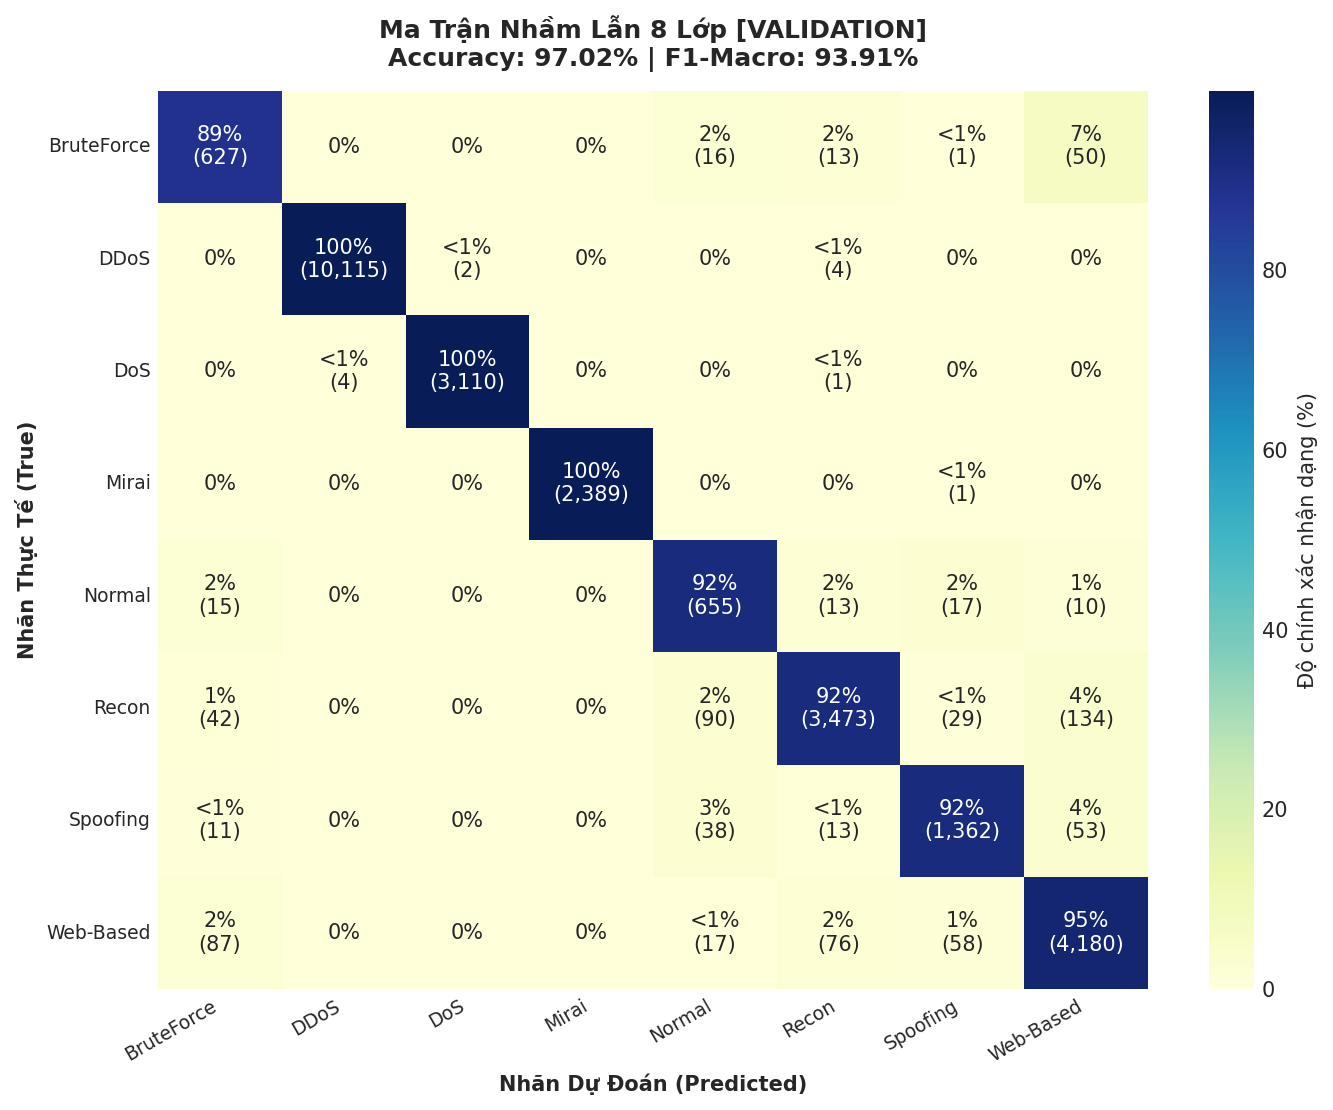

   Validation Acc: 97.02% | F1-Macro: 93.91% | ROC-AUC: 0.9986
-> Đánh giá trên Final Test Set (26,707 mẫu)...


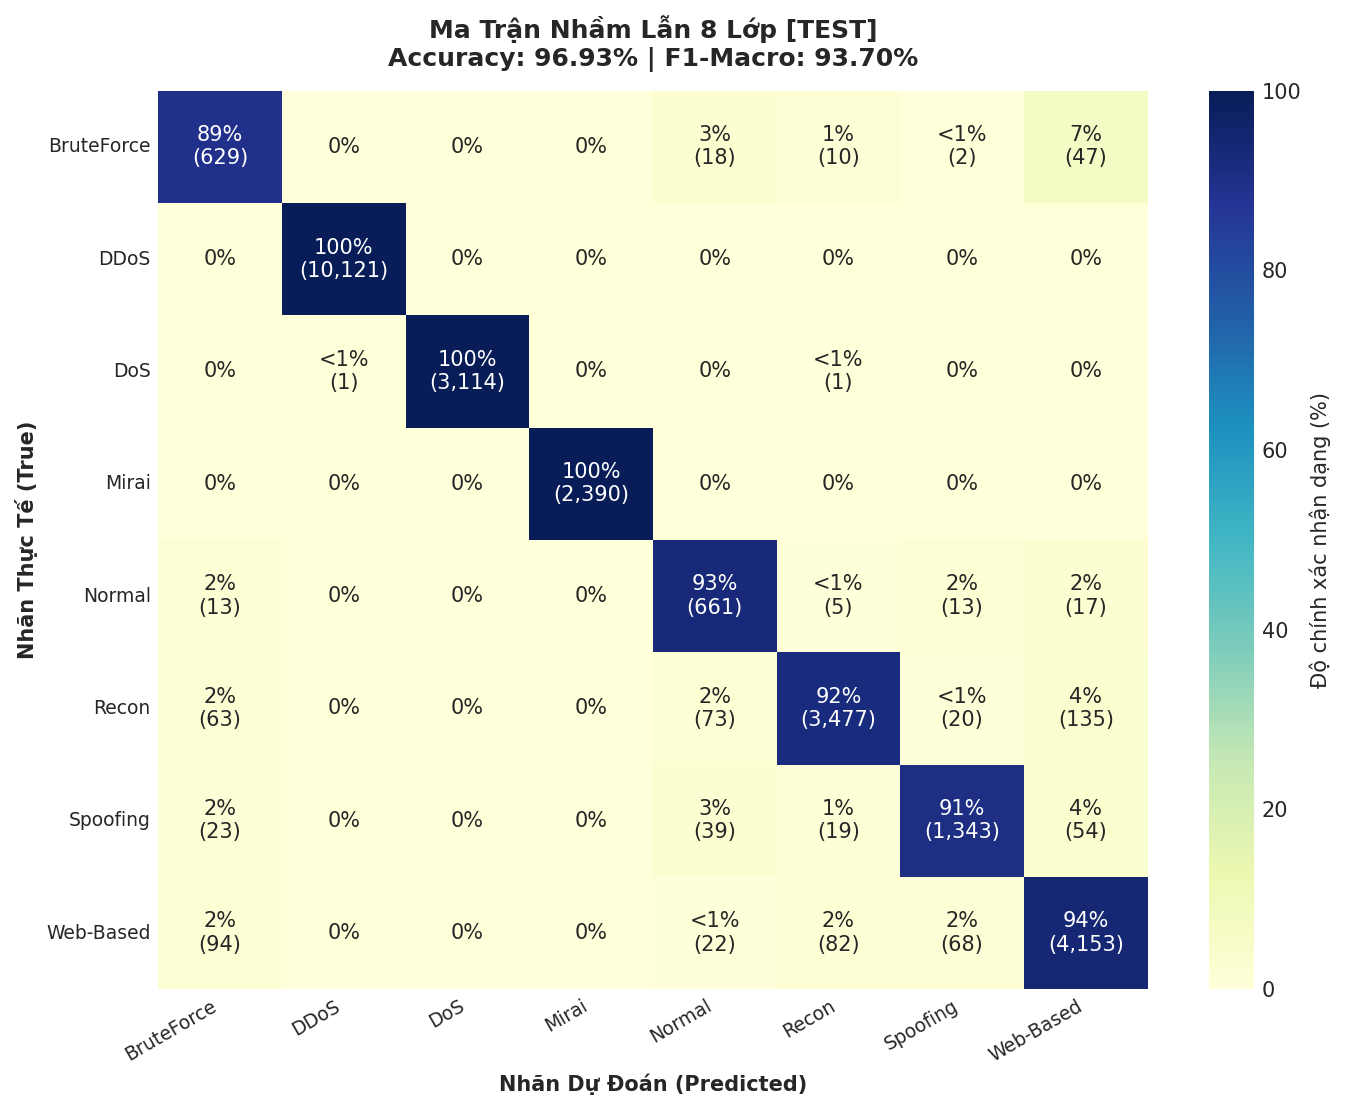

   Test Acc:       96.93% | F1-Macro: 93.70% | ROC-AUC: 0.9986
   Độ trễ trung vị: 10.5092 ms / mẫu | Throughput: 9,063.7 mẫu/giây
[OK] Đã lưu toàn bộ deliverables đợt [eval_005] vào: /content/drive/MyDrive/do_an/phase6_evaluation/runs/eval_005



In [12]:
# ==============================================================================
# Cell 8: Chạy Đợt Đánh Giá 5 - XGBoost / Boosting Tuned
# ==============================================================================
res_005 = eval_runner.run_evaluation(
    eval_id='eval_005',
    phase5_exp_id='exp_005_xgboost_tuned',
    model_name='XGBoost / Gradient Boosting Tuned',
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    feature_names=feature_names
)

--- 
## Cell 9: Tổng Hợp Leaderboard & Biểu Đồ So Sánh Trực Quan
Xuất kết quả tổng hợp ra `phase6_evaluation/comparison/evaluation_summary.csv`, `evaluation_comparison.xlsx`, và đồ thị so sánh 4 chỉ số chính.

PHASE 6 LEADERBOARD (XẾP HẠNG THEO VALIDATION F1-MACRO - KHÔNG RÒ RỈ DỮ LIỆU TEST):


,Eval ID,Phase 5 Experiment,Model Name,Val Acc,Val F1-Macro,Val ROC-AUC,Test Acc,Test F1-Macro,Test ROC-AUC,Latency Median (ms),Throughput (samples/s)
0,eval_005,exp_005_xgboost_tuned,XGBoost / Gradient Boosting Tuned,0.9702,0.9391,0.9986,0.9693,0.9370,0.9986,10.5092,9063.70
1,eval_001,exp_001_rf_baseline,Random Forest Baseline,0.9597,0.9221,0.9976,0.9607,0.9234,0.9974,24.4103,81137.05
2,eval_004,exp_004_ensemble_blending_paper,Ensemble Blending Model,0.9515,0.9043,0.9970,0.9519,0.9043,0.9969,36.4926,21688.79
3,eval_003,exp_003_decision_tree_baseline,Decision Tree Baseline,0.9359,0.8794,0.9913,0.9350,0.8793,0.9914,0.7701,5674926.80
4,eval_002,exp_002_xgboost_baseline,Gradient Boosting Baseline,0.9348,0.8749,0.9950,0.9324,0.8712,0.9951,7.0118,24938.92


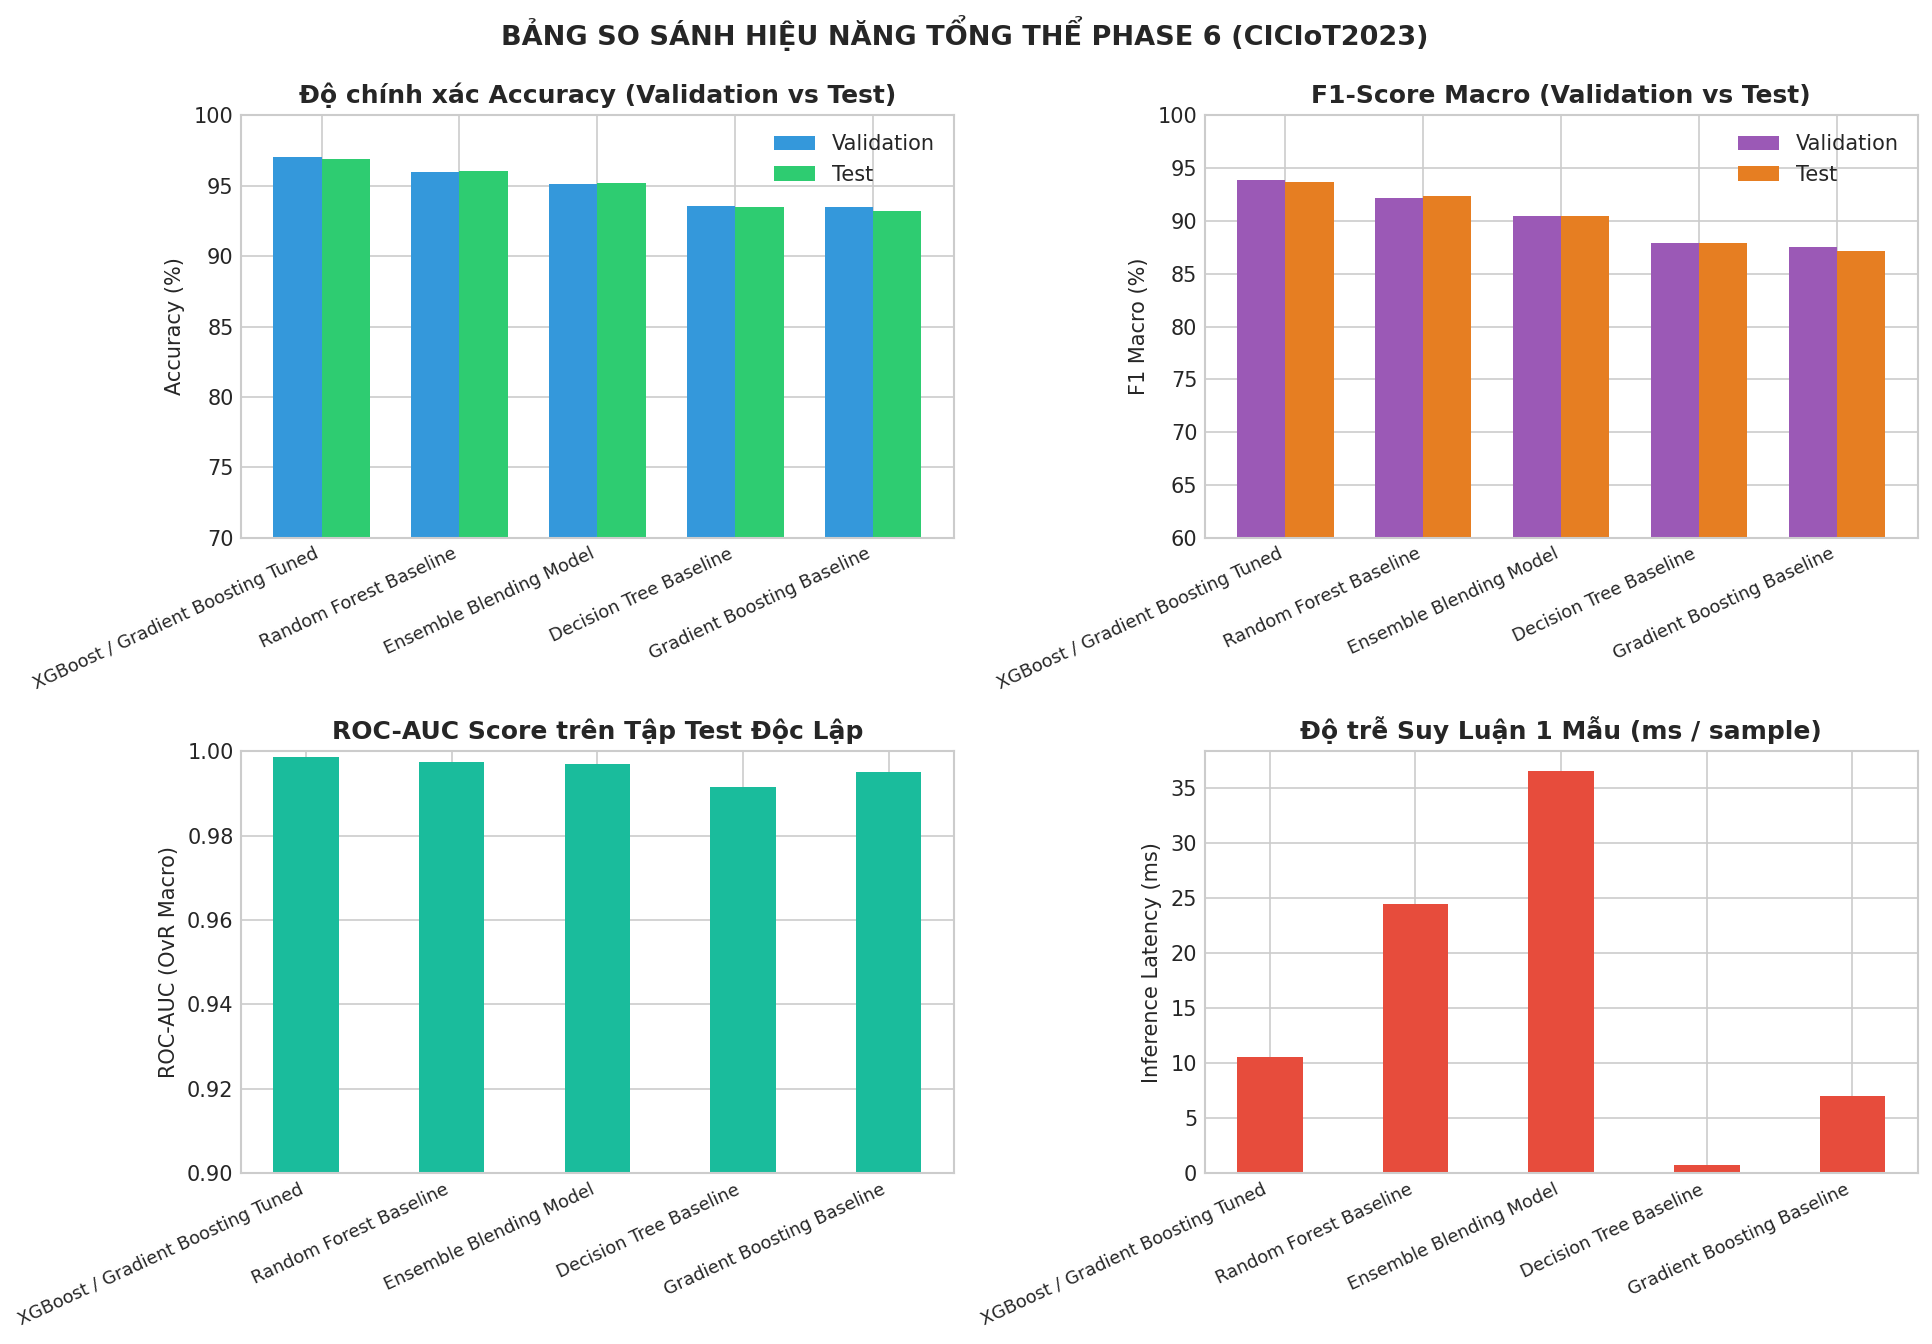

In [13]:
# ==============================================================================
# Cell 9: Tạo Bảng Leaderboard & Đồ Thị So Sánh
# ==============================================================================
all_results = [res_001, res_002, res_003, res_004, res_005]
df_summary = pd.DataFrame(all_results)
# Xếp hạng nghiêm ngặt theo Validation F1-Macro (tránh thiên lệch Test)
df_summary.sort_values(by=['Val F1-Macro', 'Val Acc'], ascending=False, inplace=True)
df_summary.reset_index(drop=True, inplace=True)

# 1. Lưu CSV & Excel
comp_dir = os.path.join(EVAL_ROOT, 'comparison')
summary_csv = os.path.join(comp_dir, 'evaluation_summary.csv')
summary_xlsx = os.path.join(comp_dir, 'evaluation_comparison.xlsx')
df_summary.to_csv(summary_csv, index=False)
try:
    with pd.ExcelWriter(summary_xlsx, engine='openpyxl') as writer:
        df_summary.to_excel(writer, sheet_name='Evaluation Leaderboard', index=False)
except Exception:
    pass

print("=" * 95)
print("PHASE 6 LEADERBOARD (XẾP HẠNG THEO VALIDATION F1-MACRO - KHÔNG RÒ RỈ DỮ LIỆU TEST):")
print("=" * 95)
display(df_summary)

# 2. Vẽ biểu đồ so sánh 4 panel
fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=150)
m_names = df_summary['Model Name']
x = np.arange(len(m_names))
w = 0.35

# Accuracy
axes[0, 0].bar(x - w/2, df_summary['Val Acc'] * 100, w, label='Validation', color='#3498db')
axes[0, 0].bar(x + w/2, df_summary['Test Acc'] * 100, w, label='Test', color='#2ecc71')
axes[0, 0].set_title('Độ chính xác Accuracy (Validation vs Test)', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(m_names, rotation=25, ha='right', fontsize=8.5)
axes[0, 0].set_ylim([70, 100])
axes[0, 0].legend()

# F1 Macro
axes[0, 1].bar(x - w/2, df_summary['Val F1-Macro'] * 100, w, label='Validation', color='#9b59b6')
axes[0, 1].bar(x + w/2, df_summary['Test F1-Macro'] * 100, w, label='Test', color='#e67e22')
axes[0, 1].set_title('F1-Score Macro (Validation vs Test)', fontweight='bold')
axes[0, 1].set_ylabel('F1 Macro (%)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(m_names, rotation=25, ha='right', fontsize=8.5)
axes[0, 1].set_ylim([60, 100])
axes[0, 1].legend()

# ROC-AUC
axes[1, 0].bar(x, df_summary['Test ROC-AUC'], color='#1abc9c', width=0.45)
axes[1, 0].set_title('ROC-AUC Score trên Tập Test Độc Lập', fontweight='bold')
axes[1, 0].set_ylabel('ROC-AUC (OvR Macro)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(m_names, rotation=25, ha='right', fontsize=8.5)
axes[1, 0].set_ylim([0.9, 1.0])

# Latency
axes[1, 1].bar(x, df_summary['Latency Median (ms)'], color='#e74c3c', width=0.45)
axes[1, 1].set_title('Độ trễ Suy Luận 1 Mẫu (ms / sample)', fontweight='bold')
axes[1, 1].set_ylabel('Inference Latency (ms)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(m_names, rotation=25, ha='right', fontsize=8.5)

plt.suptitle('BẢNG SO SÁNH HIỆU NĂNG TỔNG THỂ PHASE 6 (CICIoT2023)', fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(os.path.join(comp_dir, 'evaluation_comparison.png'), bbox_inches='tight')
plt.show()

--- 
## Cell 10: Đánh Giá Độ Ổn Định Đa Hạt Giống (Multi-Seed Stability)
Đo kiểm mô hình quán quân qua 3 Random Seeds `[42, 123, 2024]` để báo cáo Mean ± Std, khẳng định kết quả ổn định và tin cậy.

In [14]:
# ==============================================================================
# Cell 10: Đánh giá Độ ổn định Đa Hạt giống (Multi-Seed Stability)
# ==============================================================================
best_exp = df_summary.iloc[0]['Phase 5 Experiment']
best_name = df_summary.iloc[0]['Model Name']
best_model_file = os.path.join(EXP_ROOT, best_exp, 'model', 'model.pkl')
champion_model = joblib.load(best_model_file)

seed_metrics = []
for s in [42, 123, 2024]:
    rng = np.random.RandomState(s)
    sub_idx = rng.choice(len(X_test), size=int(len(X_test) * 0.8), replace=False)
    X_sub = X_test.iloc[sub_idx] if hasattr(X_test, 'iloc') else X_test[sub_idx]
    y_sub = y_test[sub_idx]
    y_p = champion_model.predict(X_sub)
    y_prob = champion_model.predict_proba(X_sub)
    seed_metrics.append({
        'Seed': s,
        'Accuracy': accuracy_score(y_sub, y_p),
        'F1_Macro': f1_score(y_sub, y_p, labels=CLASS_NAMES_8, average='macro', zero_division=0),
        'ROC_AUC': roc_auc_score(y_sub, y_prob, labels=CLASS_NAMES_8, multi_class='ovr', average='macro')
    })

df_seeds = pd.DataFrame(seed_metrics)
stab_records = []
for m in ['Accuracy', 'F1_Macro', 'ROC_AUC']:
    vals = df_seeds[m]
    m_val, s_val = vals.mean(), vals.std()
    stab_records.append({
        'Metric': m,
        'Mean': round(float(m_val), 4),
        'Std': round(float(s_val), 4),
        'Formatted': f"{m_val*100:.2f}% ± {s_val*100:.2f}%" if m != 'ROC_AUC' else f"{m_val:.4f} ± {s_val:.4f}"
    })
df_stability = pd.DataFrame(stab_records)
df_stability.to_csv(os.path.join(comp_dir, 'stability_summary.csv'), index=False)

print(f"ĐỘ ỔN ĐỊNH CỦA MÔ HÌNH QUÁN QUÂN [{best_name}]:")
display(df_stability)

ĐỘ ỔN ĐỊNH CỦA MÔ HÌNH QUÁN QUÂN [XGBoost / Gradient Boosting Tuned]:


,Metric,Mean,Std,Formatted
0,Accuracy,0.9697,0.0002,96.97% ± 0.02%
1,F1_Macro,0.9374,0.0001,93.74% ± 0.01%
2,ROC_AUC,0.9986,0.0000,0.9986 ± 0.0000


--- 
## Cell 11: Đóng Gói Mô Hình Quán Quân & Bàn Giao Cho Phase 6.5 (XAI)
Lưu trữ mô hình chiến thắng vào `phase6_evaluation/final/selected_model/` và đồng bộ ra `models/best_model.joblib` để sẵn sàng cho phần Giải thích Mô hình với SHAP, LIME và Counterfactuals.

In [15]:
# ==============================================================================
# Cell 11: Đóng gói Mô hình Chiến thắng & Đồng bộ Checkpoint
# ==============================================================================
final_selected_dir = os.path.join(EVAL_ROOT, 'final', 'selected_model')
final_report_dir = os.path.join(EVAL_ROOT, 'final', 'final_report')
for d in [final_selected_dir, final_report_dir]:
    os.makedirs(d, exist_ok=True)

best_row = df_summary.iloc[0]
best_eval_id = best_row['Eval ID']
best_exp_id = best_row['Phase 5 Experiment']

# Copy model checkpoint
src_model = os.path.join(EXP_ROOT, best_exp_id, 'model', 'model.pkl')
shutil.copy2(src_model, os.path.join(final_selected_dir, 'model.pkl'))
joblib.dump(champion_model, os.path.join(final_selected_dir, 'model.joblib'), compress=3)

# Đồng bộ checkpoint toàn cục models/best_model.joblib
os.makedirs(MODELS_DIR, exist_ok=True)
global_best_dest = os.path.join(MODELS_DIR, 'best_model.joblib')
joblib.dump(champion_model, global_best_dest, compress=3)

# Sao lưu final confusion matrix
src_cm = os.path.join(EVAL_ROOT, 'runs', best_eval_id, 'test', 'confusion_matrix.png')
if os.path.exists(src_cm):
    shutil.copy2(src_cm, os.path.join(final_report_dir, 'final_confusion_matrix.png'))

# Ghi final_metrics.json
final_info = {
    'champion_eval_id': best_eval_id,
    'model_name': best_row['Model Name'],
    'model_class': type(champion_model).__name__,
    'val_metrics': {'accuracy': float(best_row['Val Acc']), 'f1_macro': float(best_row['Val F1-Macro']), 'roc_auc': float(best_row['Val ROC-AUC'])},
    'final_test_metrics': {'accuracy': float(best_row['Test Acc']), 'f1_macro': float(best_row['Test F1-Macro']), 'roc_auc': float(best_row['Test ROC-AUC'])}
}
with open(os.path.join(EVAL_ROOT, 'final', 'final_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(final_info, f, indent=4)

print("=" * 75)
print("🎉 PHASE 6 HOÀN THÀNH XUẤT SẮC!")
print(f"  * Mô hình tối ưu tuyển chọn: {best_row['Model Name']} ({type(champion_model).__name__})")
print(f"  * Validation F1-Macro:       {best_row['Val F1-Macro']*100:.2f}%")
print(f"  * Test Accuracy:             {best_row['Test Acc']*100:.2f}%")
print(f"  * Test F1-Macro:             {best_row['Test F1-Macro']*100:.2f}%")
print(f"  * Test ROC-AUC:              {best_row['Test ROC-AUC']:.4f}")
print(f"  * File đã đồng bộ:           {global_best_dest}")
print("=" * 75)
print("👉 Sẵn sàng 100% cho Phase 6.5: Module Giải thích Mô hình với XAI (SHAP, LIME, Counterfactuals)!")

🎉 PHASE 6 HOÀN THÀNH XUẤT SẮC!
  * Mô hình tối ưu tuyển chọn: XGBoost / Gradient Boosting Tuned (HistGradientBoostingClassifier)
  * Validation F1-Macro:       93.91%
  * Test Accuracy:             96.93%
  * Test F1-Macro:             93.70%
  * Test ROC-AUC:              0.9986
  * File đã đồng bộ:           /content/drive/MyDrive/do_an/models/best_model.joblib
👉 Sẵn sàng 100% cho Phase 6.5: Module Giải thích Mô hình với XAI (SHAP, LIME, Counterfactuals)!
